# Week 10 - 피처 엔지니어링 및 모델 해석
**빅데이터 응용 실습 | Feature Importance, SHAP, LIME**

- 성능 중심의 맹심 -> 설명 가능한 모델

### 우리의 현주소
- 다양한 모델 학습(Random Forest, XGBoost 등)
- 하이퍼파라미터 튜닝을 통한 정확도(Accuracy) 극대화
- 교차검증으로 성능 입증 완료

### 현업의 필수 질문
- 이 데이터에서 가장 결정적인 역할을 한 변수는 무엇인가?
- 특정 샘플을 '긍정(1)'으로 분류한 근거는 무엇인가?
- 이 결과를 비전문가(고객, 경영잔)에게 납득시킬 수 있는가?

**설명 가능성이 결여된 뛰어난 성능은 실무에서 결코 신뢰를 얻을 수 없음**

---

## Feature engenering

**원본 데이터를 기계가 학습하기 좋고, 인간이 이해하기 쉬운 형태로 변환하는 과정**
- Raw Data -> Feature Engenering -> Model & Insight

**정제된 피처는 모델의 성능을 극대화 할 뿐만 아니라, 향후 도출될 변수의 중요도의 직관적 해석을 가능하게 함**


---


## Feature Importance로 모델 전체를 지배하는 핵심 변수 찾기
- 불순도 감소 기반 중요도

### 핵심 질문: 이 모델에서 어떤 변수가 예측에 가장 큰 영향을 주었는가? (Global View)

### 작동 원리 (트리 모델 기준)
* 특정 변수가 트리의 분기(Split)에서 자주 사용될수록 중요도가 상승.
* 분기 후 클래스의 불순도(Information Gain, Gini)를 얼마나 크게 감소시켰는지 측정.

### 장점 및 한계
* **[+]** 계산이 매우 빠르고 직관적인 전역적(Global) 해석 제공.
* **[-]** 연속형 변수에 유리하며, 상관관계가 높은 변수들 간에 중요도가 분산되는 취약점 존재.
---

## 순열 중요도 (Permutation Importance)
- 데이터의 배열을 무너뜨려 변수의 진짜 가치를 증명

### 변수 중요도 측정 원리 (Permutation Importance)

과정은 크게 3단계로 이루어집니다:

1. **정상 데이터**
   * **기준 성능 (Base Performance):** 원본 데이터로 모델의 기본 성능을 측정합니다. (마치 젠가 탑이 온전히 서 있는 상태와 같습니다.)

2. **무작위 섞기 (Shuffle)**
   * 특정 변수의 값을 무작위로 섞어 해당 변수가 가진 정보를 망가뜨립니다. (젠가 탑 중간의 블록 하나를 빼거나 흔드는 과정과 같습니다.)

3. **성능 하락 측정**
   * **성능 폭락 = 모델이 강하게 의존하던 결정적 중요 변수:** 해당 변수를 섞었을 때 성능이 크게 떨어진다면, 그 변수는 예측에 매우 중요한 역할을 하고 있었음을 의미합니다. (중요한 블록을 건드려 젠가 탑이 무너지는 상황)
   * **성능 변화 없음 = 예측에 기여하지 않는 불필요한 변수:** 해당 변수를 섞어도 성능에 변화가 없다면, 그 변수는 모델 예측에 큰 영향력이 없음을 의미합니다. (중요하지 않은 블록이라 젠가 탑이 그대로 유지되는 상황)

---

### 장점 및 단점

| 구분 | 내용 |
| :--- | :--- |
| **장점 (+)** | **[+]** 트리 모델에 국한되지 않고 모든 알고리즘에 적용 가능한 모델 독립성(Model-agnostic). |
| **단점 (-)** | **[-]** 매번 성능을 재평가해야 하므로 계산 비용이 크고, 강한 상관관계의 변수가 존재 시 해석 왜곡 우려. |
---

## 모델 전체 관점에서 '어떤 변수가 예측에 가장 큰 영향을 주었는가?'

### 1. 트리 기반 중요도 (Impurity Decrease)
* **개념:** Decision Tree나 Random Forest에서, 특정 변수가 노드를 분할할 때 **불순도**를 얼마나 크게 감소시켰는지 측정.
* **특징:** 계산이 매우 빠르고 직관적. 단, 연속형 변수나 카디널리티가 많은 변수에 **과대적합**될 위험 존재.

### 2. 순열 중요도 (Permutation Importance)
* **아이디어:** 이 변수가 정말 중요하다면, 값을 무작위로 섞었을 때(Shuffle) 모델 성능이 폭락할 것이다!
* **과정:** 원본 성능 측정 -> 특정 피처 셔플링 -> 성능 하락폭 측정.
* **특징:** 어떤 모델(Model-agnostic)에도 적용 가능하지만 계산 비용이 큼.

---
## 왜 우리는 더 발전된 해석 도구가 필요한가?

* **상관관계의 함정 (Correlation)**
  비슷한 두 변수(예: '월 소득'과 '연봉')가 존재할 경우, 중요도가 둘로 나뉘어 실제보다 덜 중요한 것처럼 과소평가될 수 있음.

* **개별 샘플의 설명 불가 (Global vs Local)**
  Feature Importance는 '전체 모델'에서 평균적으로 중요한 변수만 알려줌.
  > **❗ 치명적 한계:** 모델 전체로는 '소득'이 제일 중요하지만, 오늘 대출이 거절된 김철수 고객의 거절 사유는 '소득'이 아니라 '연체 기록' 때문일 수 있음. 이를 전혀 설명하지 못함.

* **방향성 부재 (No Direction)**
  특정 변수가 '중요하다'는 것은 알지만, 그 변수값이 클 때 예측값을 높이는지(+) 낮추는지(-) 방향성을 알 수 없음.


| Global Explanation (전역 해석) - '숲을 보는 관점' | Local Explanation (국소 해석) - '나무를 보는 관점' |
| :--- | :--- |
| **개념:** 모델 전체의 동작 원리와 전반적인 변수의 영향력 파악. | **개념:** 개별 데이터 포인트(특정 고객, 특정 환자)에 대한 예측 결과의 구체적 원인 파악. |
| **질문:** 우리 회사의 이탈 예측 모델에서 가장 중요한 요인 Top 5는 무엇인가? | **질문:** VIP 고객 A가 다음 달에 이탈한다고 예측한 정확한 이유는 무엇인가? |
| **사용 도구:** Feature Importance, Permutation Importance | **사용 도구:** LIME, SHAP |

> **💡 블랙박스 모델을 비즈니스에 완벽히 적용하려면 숲(Global)과 나무(Local)를 모두 설명할 수 있어야 합니다.**
---

## 특정 데이터 포인트 하나의 예측 결과만 '국소적'으로 설명하는 도구

> **"전체 모델(복잡한 곡선)을 이해하려 하지 말고, 내가 관심 있는 데이터 딱 하나 주변의 좁은 영역만 단순한 직선(선형모델)으로 그려서 이해하자."**

- LIME(Local Interpretable Model-agnostic Explanations)

### 분석 과정 (4단계)

1. **타겟 선정:** 설명하고 싶은 고객 A 선택
2. **데이터 교란 (Perturbation):** 고객 A 주변에 노이즈를 주어 가짜 데이터 무수히 생성
3. **단순 모델 학습:** 해당 영역(Local Region)에만 맞는 단순한 선형 회귀 모델 학습
4. **계수 해석:** 고객 A 근처에서 변수의 영향력 직관적 설명

---

### 장점 및 단점

* **장점 (+):** 어떤 모델이든 적용 가능하며 개별 사례 설명에 매우 직관적.
* **단점 (-):** 샘플링 방식에 따라 매번 결과가 달라질 수 있는 불안정성 존재.

---
## 도구 3. SHAP (Shapley Additive exPlanations)

> **"여러 변수가 협력하여 '예측'이라는 결과를 만들었을 때, 각 변수에게 공헌도를 얼마나 '공정하게' 나누어 줄 것인가?"**

### 비유: 팀 프로젝트 보너스 분배

* **상황:** 팀원 A, B, C (변수들)가 프로젝트를 수행해 100만 원의 성과(최종 예측값) 도출.
* **계산법:** A가 혼자 했을 때, A+B가 했을 때, B+C가 했을 때 등 **모든 가능한 조합**에서의 성과를 계산.
* **결과:** 각 팀원이 합류할 때마다 평균적으로 기여한 가치(**Marginal Contribution**)를 계산하여 보너스 분배.

👉 **이것이 바로 SHAP Value 입니다!**

---

### 💡 SHAP의 강력함
* **이론적 일관성(Consistency) 보장:** 다른 변수들이 어떻게 변하든 특정 변수의 절대적 기여도를 가장 공정하고 수학적으로 완벽하게 수치화합니다.
* **전역(Global) + 국소(Local) 해석 모두 가능**합니다.

**핵심 Insight: SHAP값이 양수(+)면 타겟 예측값을 높이는 방향으로 기여하고, 음수(-)면 예측값을 낮추는 방향으로 기여함을 명확히 시각화**



---
![스크린샷 2026-05-04 오후 12.05.06.png](<attachment:스크린샷 2026-05-04 오후 12.05.06.png>)
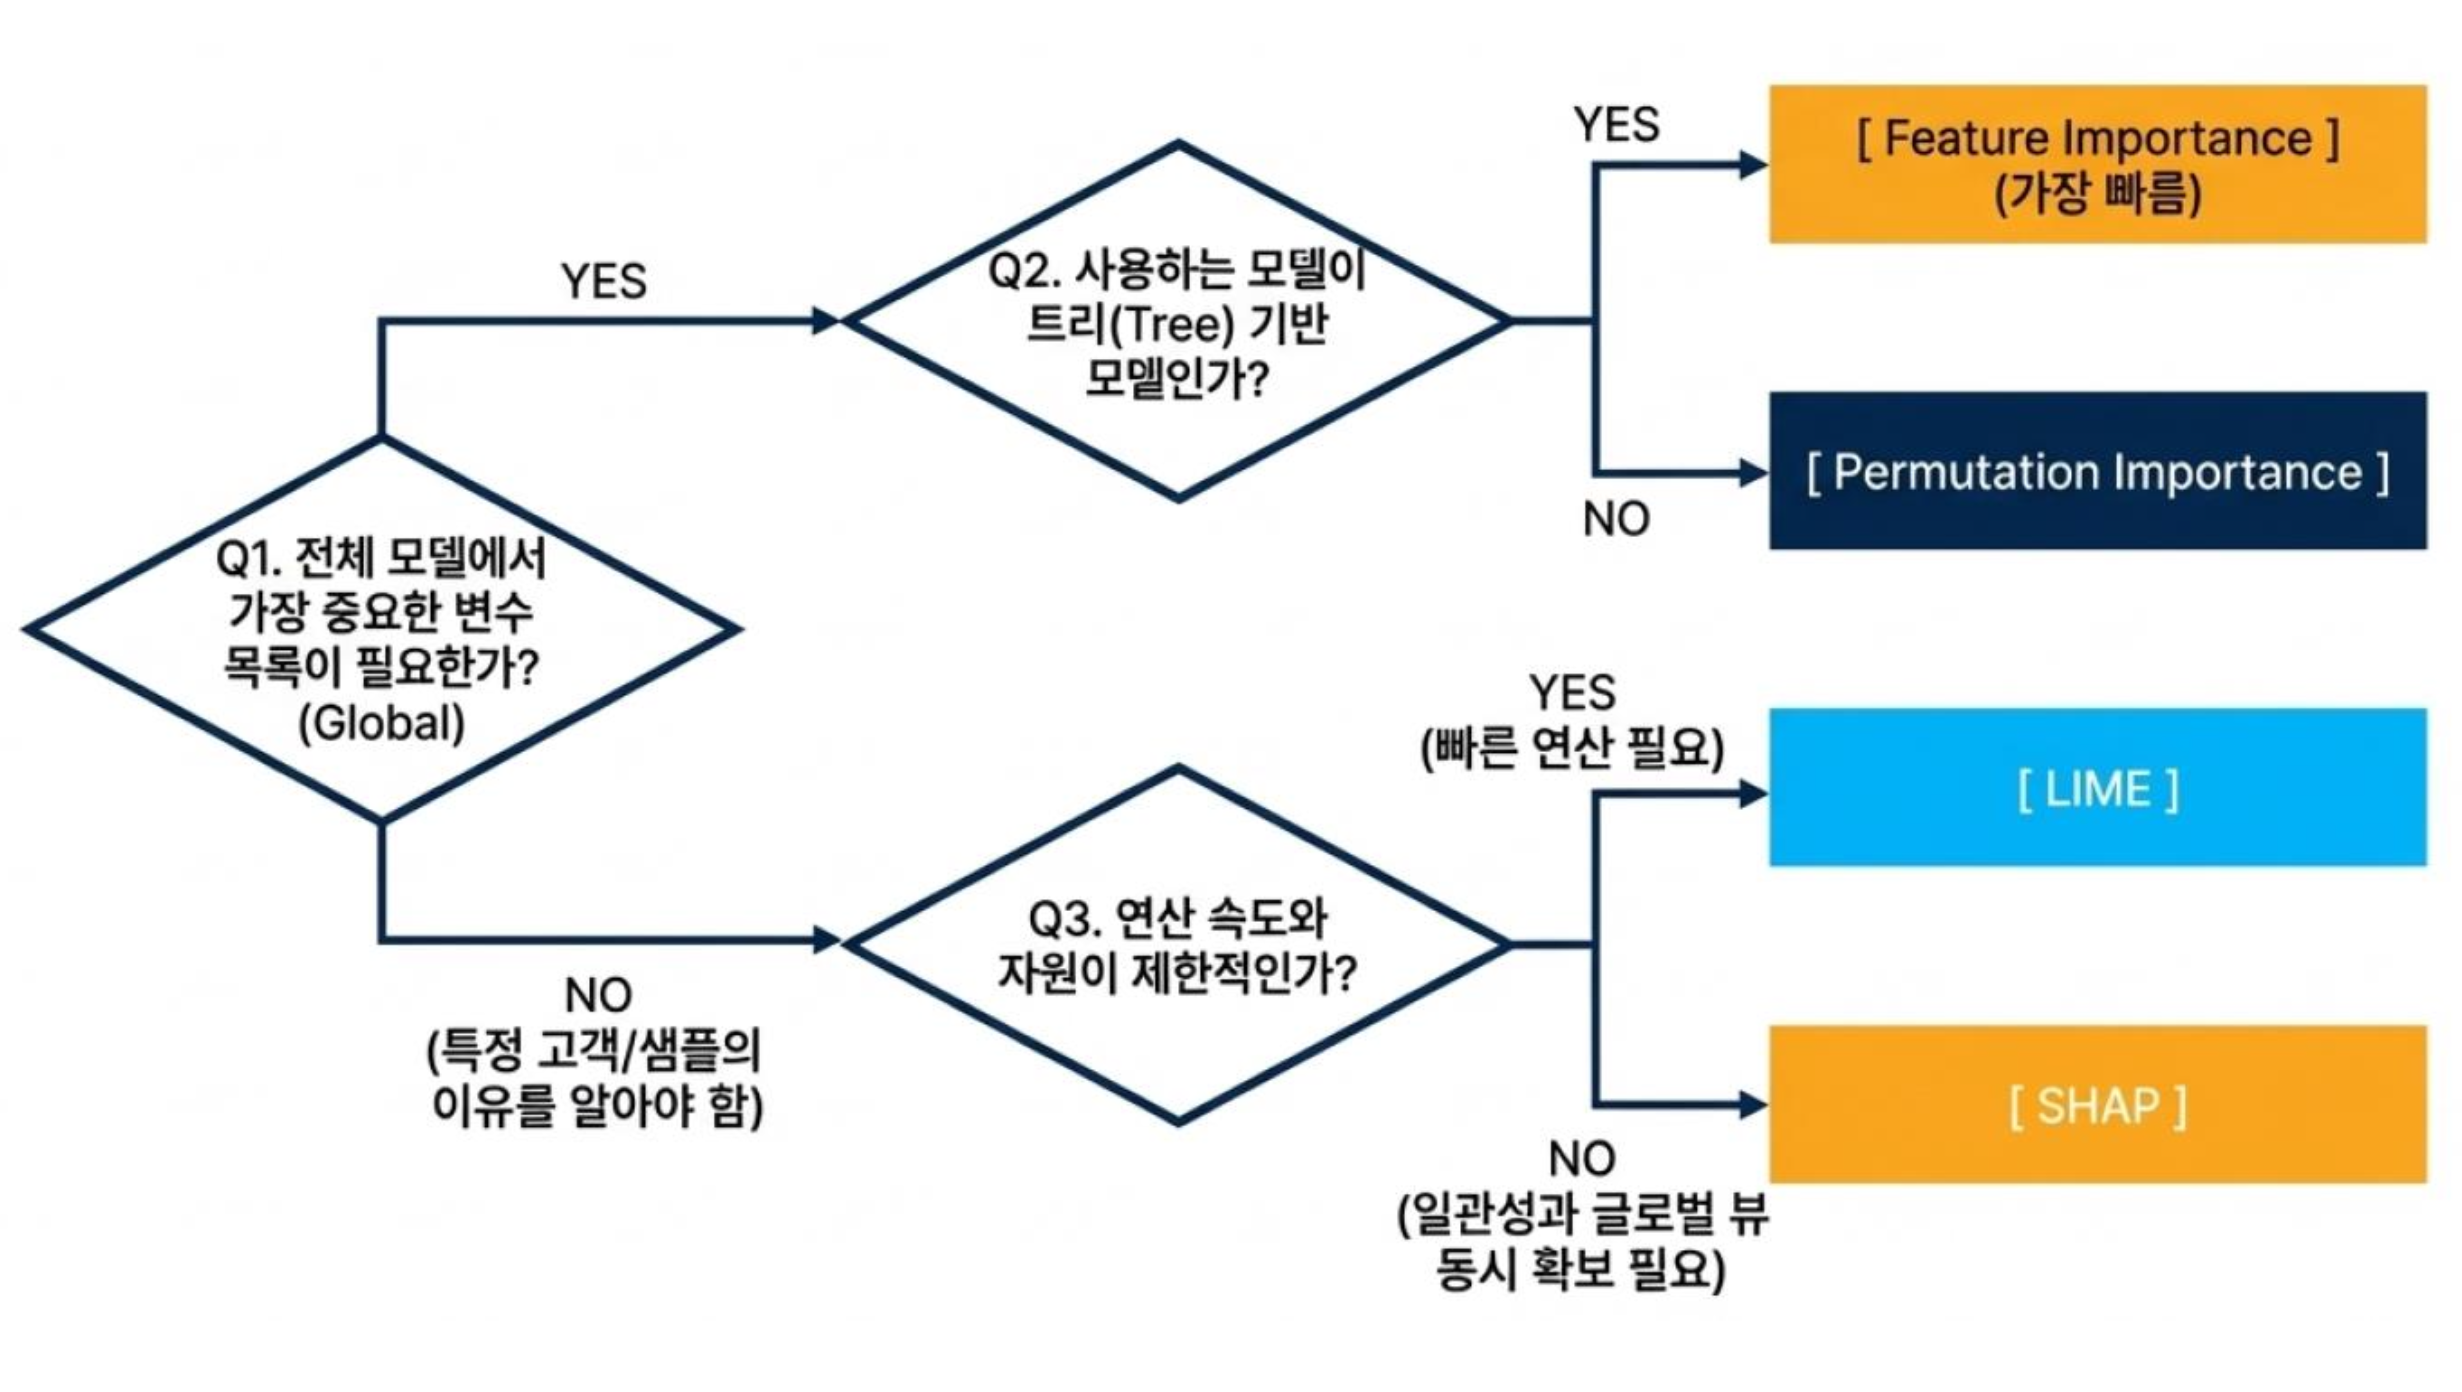

## 분석 파이프라인 (9단계)

1. **환경 설정**: 라이브러리 로드, 드라이브 마운트
2. **데이터 로드**: CSV 파일 읽기, shape 확인
3. **Train/Test 분할**: 7:3 비율, stratify 적용
4. **피처 엔지니어링**: 로그 변환, 비율 변수 생성
5. **기준 모델**: Logistic Regression 학습
6. **Random Forest**: 앙상블 모델 학습
7. **Feature Importance**: 변수 중요도 분석
8. **Permutation Importance**: 성능 기반 중요도
9. **SHAP/LIME**: 모델 해석 및 설명
